# Feature Scaling and Normalization - Lab

## Introduction
In this lab, you'll practice your feature scaling and normalization skills!

## Objectives
You will be able to:
* Identify if it is necessary to perform log transformations on a set of features
* Perform log transformations on different features of a dataset
* Determine if it is necessary to perform normalization/standardization for a specific model or set of data
* Compare the different standardization and normalization techniques
* Use standardization/normalization on features of a dataset

## Back to the Ames Housing data

Let's import our Ames Housing data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn')

ames = pd.read_csv('ames.csv')

## Look at the histograms for the continuous variables

Since there are so many features it is helpful to filter the columns by datatype and number of unique values. A heuristic you might use to select continous variables might be a combination of features that are not object datatypes and have at least a certain amount of unique values.

In [25]:
ames_int = ames.select_dtypes(include='int64', exclude='object')
ames_int.nunique()
ames_over_100 = ames_int.loc[:, ames_int.nunique() > 100]
ames_over_100

,Id,LotArea,YearBuilt,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,SalePrice
0,1,8450,2003,706,0,150,856,856,854,1710,548,0,61,0,208500
1,2,9600,1976,978,0,284,1262,1262,0,1262,460,298,0,0,181500
2,3,11250,2001,486,0,434,920,920,866,1786,608,0,42,0,223500
3,4,9550,1915,216,0,540,756,961,756,1717,642,0,35,272,140000
4,5,14260,2000,655,0,490,1145,1145,1053,2198,836,192,84,0,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,7917,1999,0,0,953,953,953,694,1647,460,0,40,0,175000
1456,1457,13175,1978,790,163,589,1542,2073,0,2073,500,349,0,0,210000
1457,1458,9042,1941,275,0,877,1152,1188,1152,2340,252,0,60,0,266500
1458,1459,9717,1950,49,1029,0,1078,1078,0,1078,240,366,0,112,142125


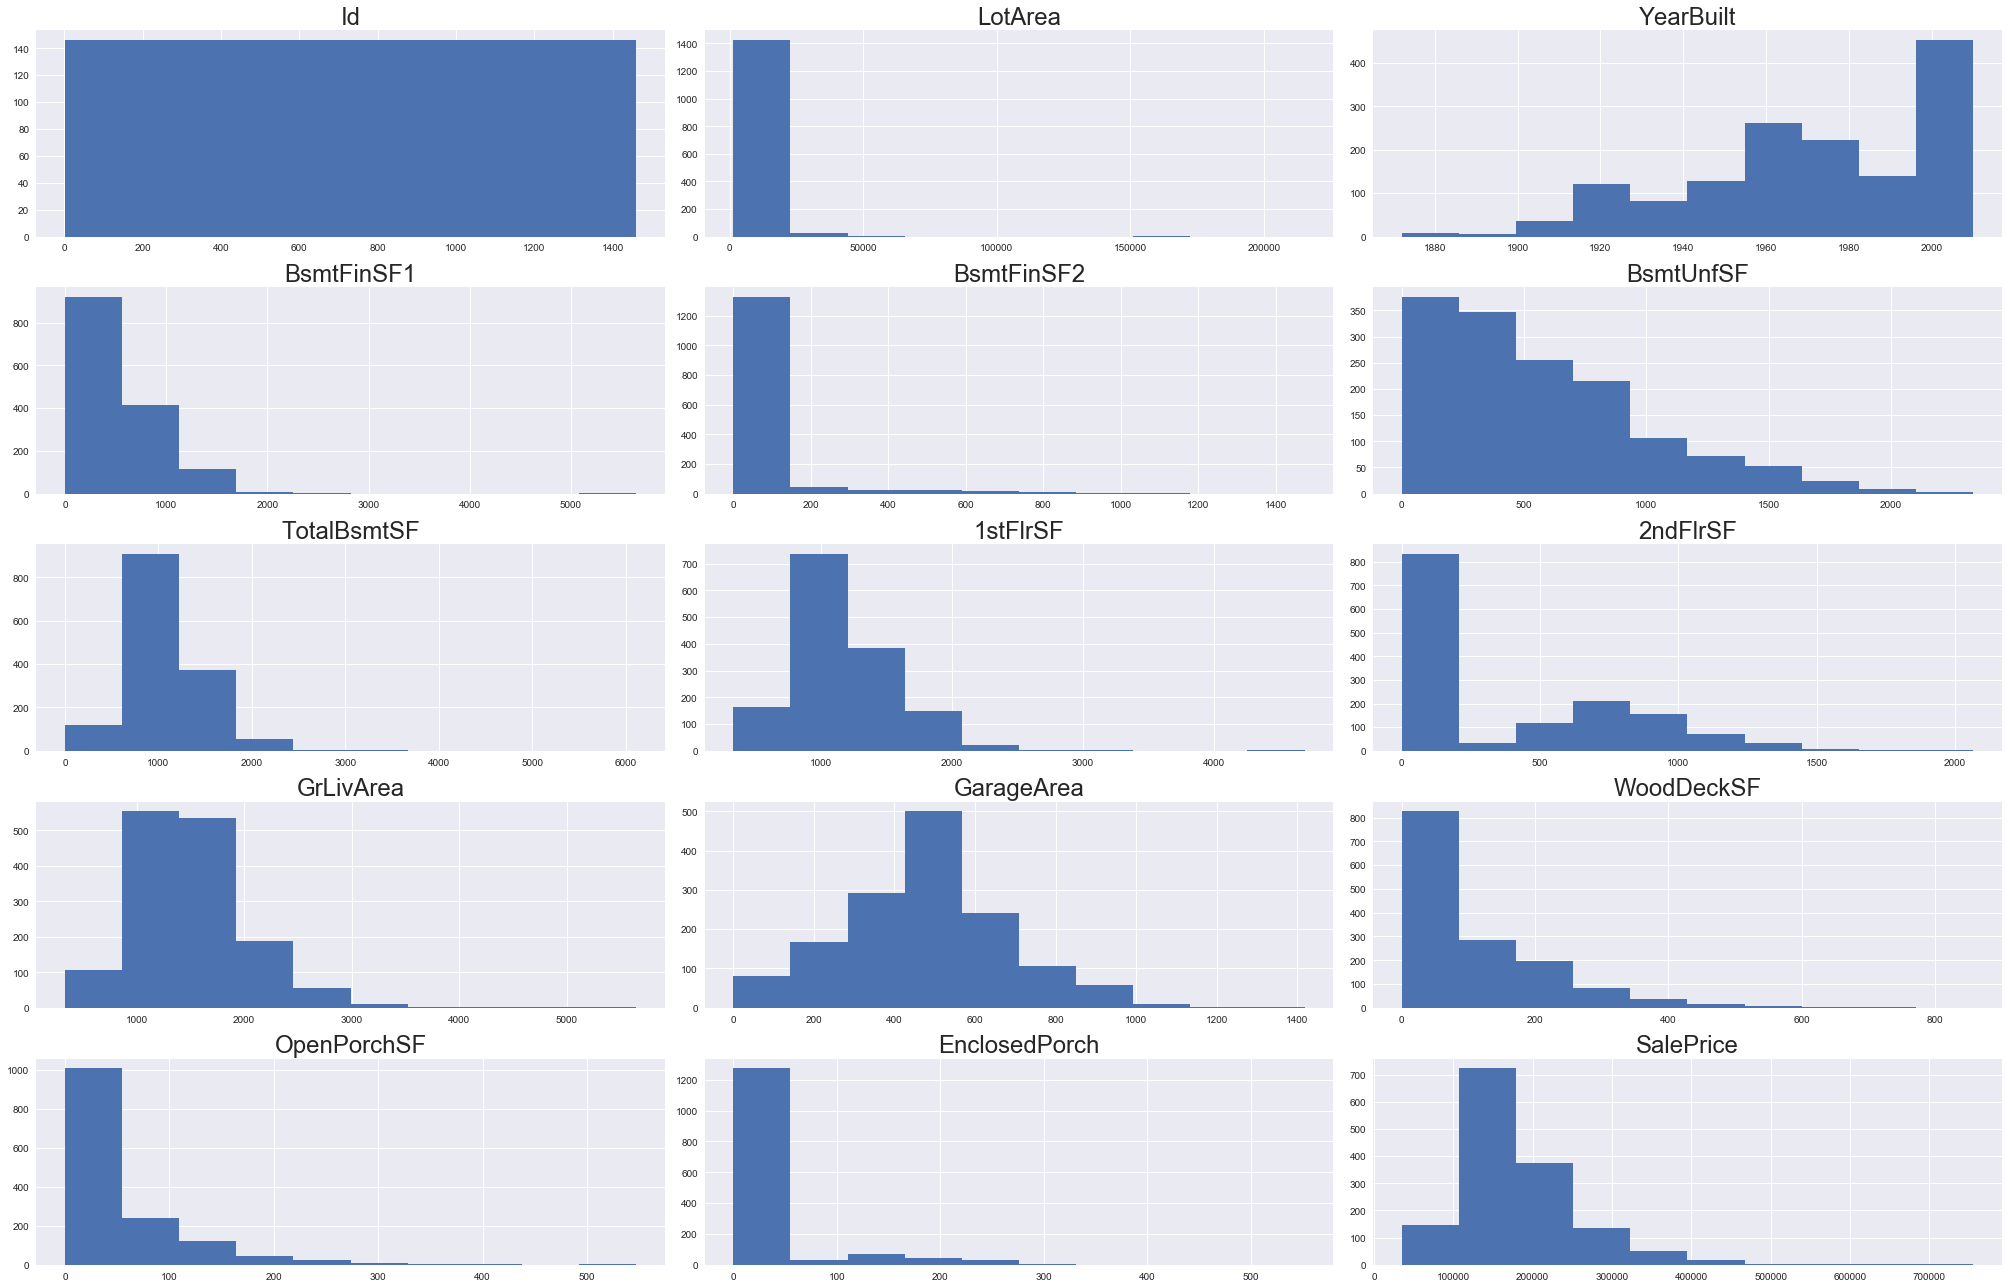

In [35]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(28,18))
categories = [column for column in ames_over_100.columns]

for col, ax in zip(categories, axes.flatten()):
    ax.hist(ames_over_100[col])
    ax.set_title(col, fontdict={'fontsize': 24})
fig.tight_layout()

We can see from our histogram of the contiuous features that there are many examples where there are a ton of zeros. For example, WoodDeckSF (square footage of a wood deck) gives us a positive number indicating the size of the deck and zero if no deck exists. It might have made sense to categorize this variable to "deck exists or not (binary variable 1/0). Now you have a zero-inflated variable which is cumbersome to work with.

Lets drop these zero-inflated variables for now and select the features which don't have this characteristic.

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fc185e8a048>,
      dtype=object)

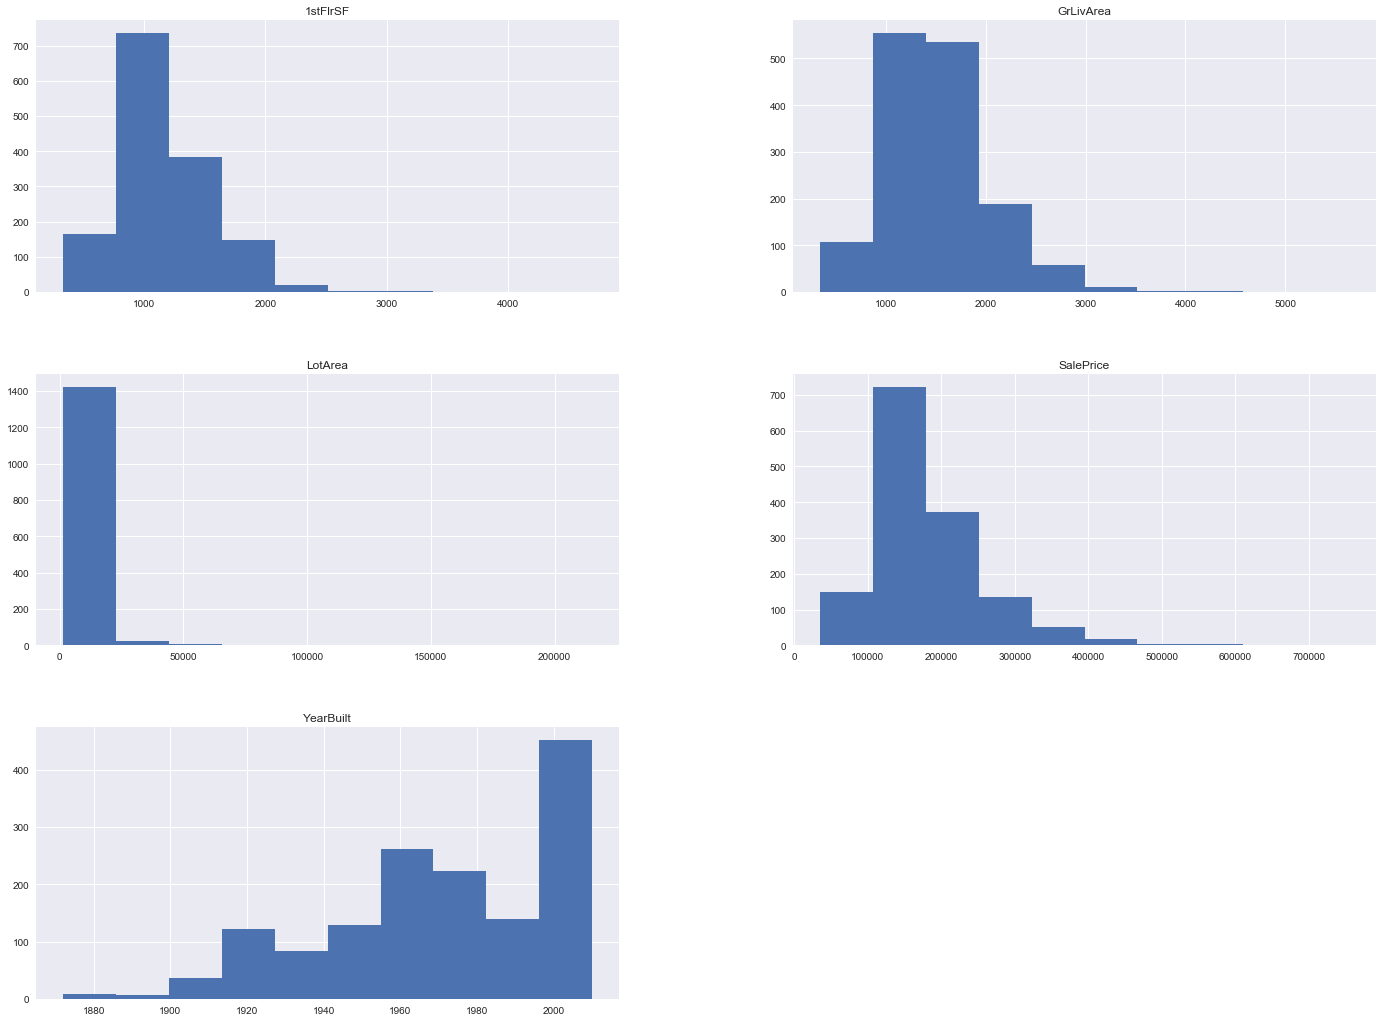

In [40]:
# Select non zero-inflated continuous features as ames_cont
ames_cont = ames_over_100[['LotArea', 'YearBuilt', '1stFlrSF', 'GrLivArea', 'SalePrice']]
ames_cont.hist(figsize=(24,18))

## Perform log transformations for the variables where it makes sense

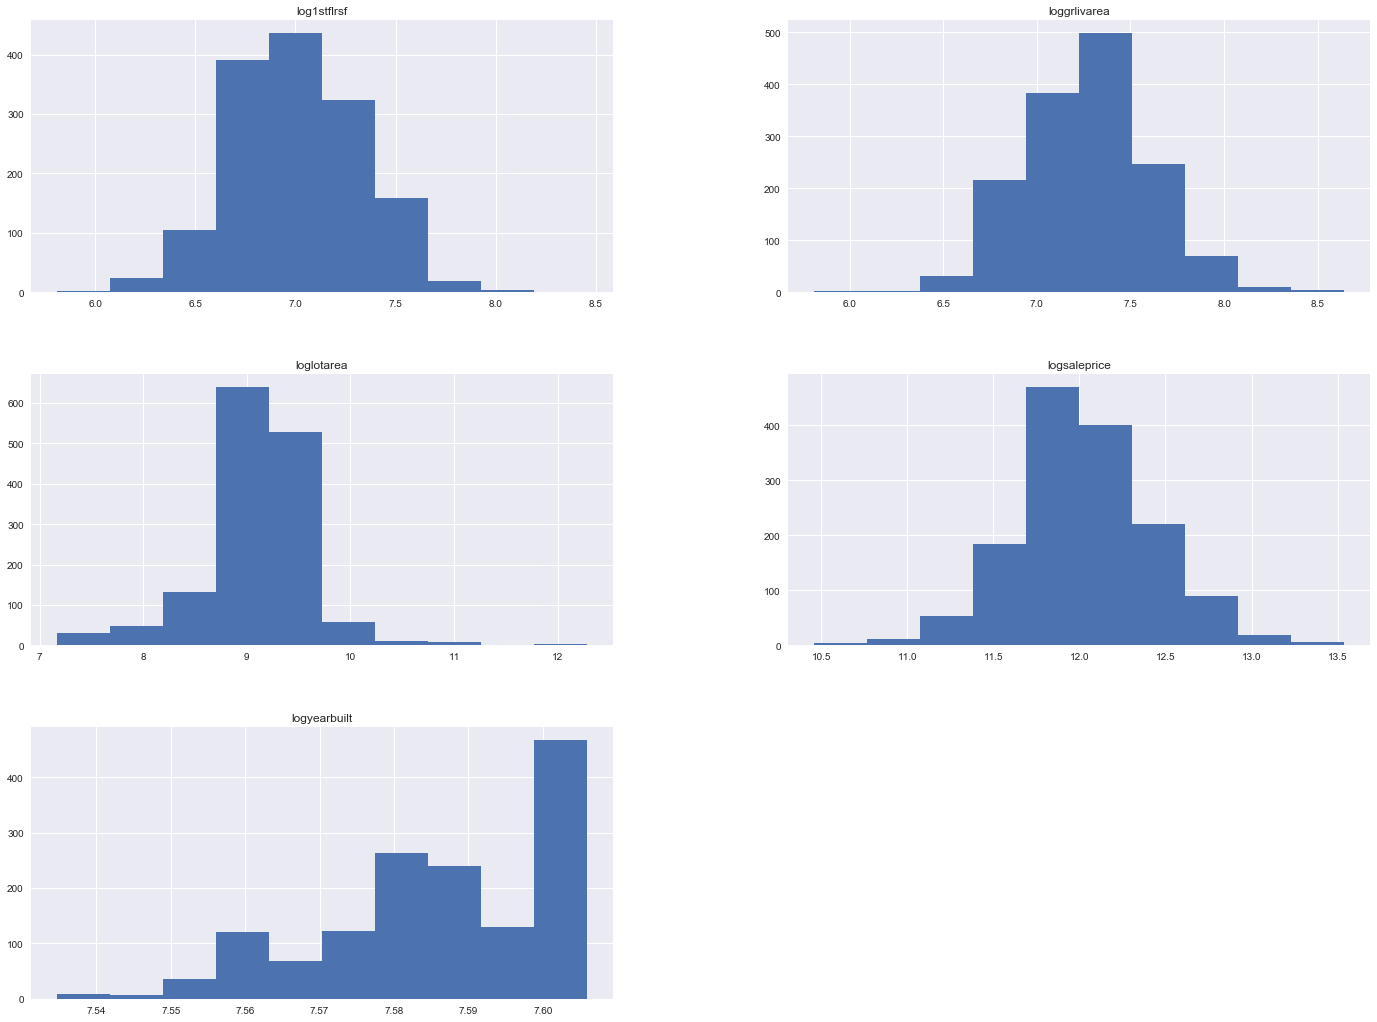

In [44]:
# Your code here
import numpy as np
ames_log = pd.DataFrame([])
ames_log['loglotarea'] = np.log(ames_cont['LotArea'])
ames_log['logyearbuilt'] = np.log(ames_cont['YearBuilt'])
ames_log['log1stflrsf'] = np.log(ames_cont['1stFlrSF'])
ames_log['loggrlivarea'] = np.log(ames_cont['GrLivArea'])
ames_log['logsaleprice'] = np.log(ames_cont['SalePrice'])
ames_log.hist(figsize  = (24, 18));

## Standardize the continuous variables

Store your final features in a DataFrame `features_final`: 

In [57]:
import sklearn
from sklearn.preprocessing import StandardScaler

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fc1873a8828>,
      dtype=object)

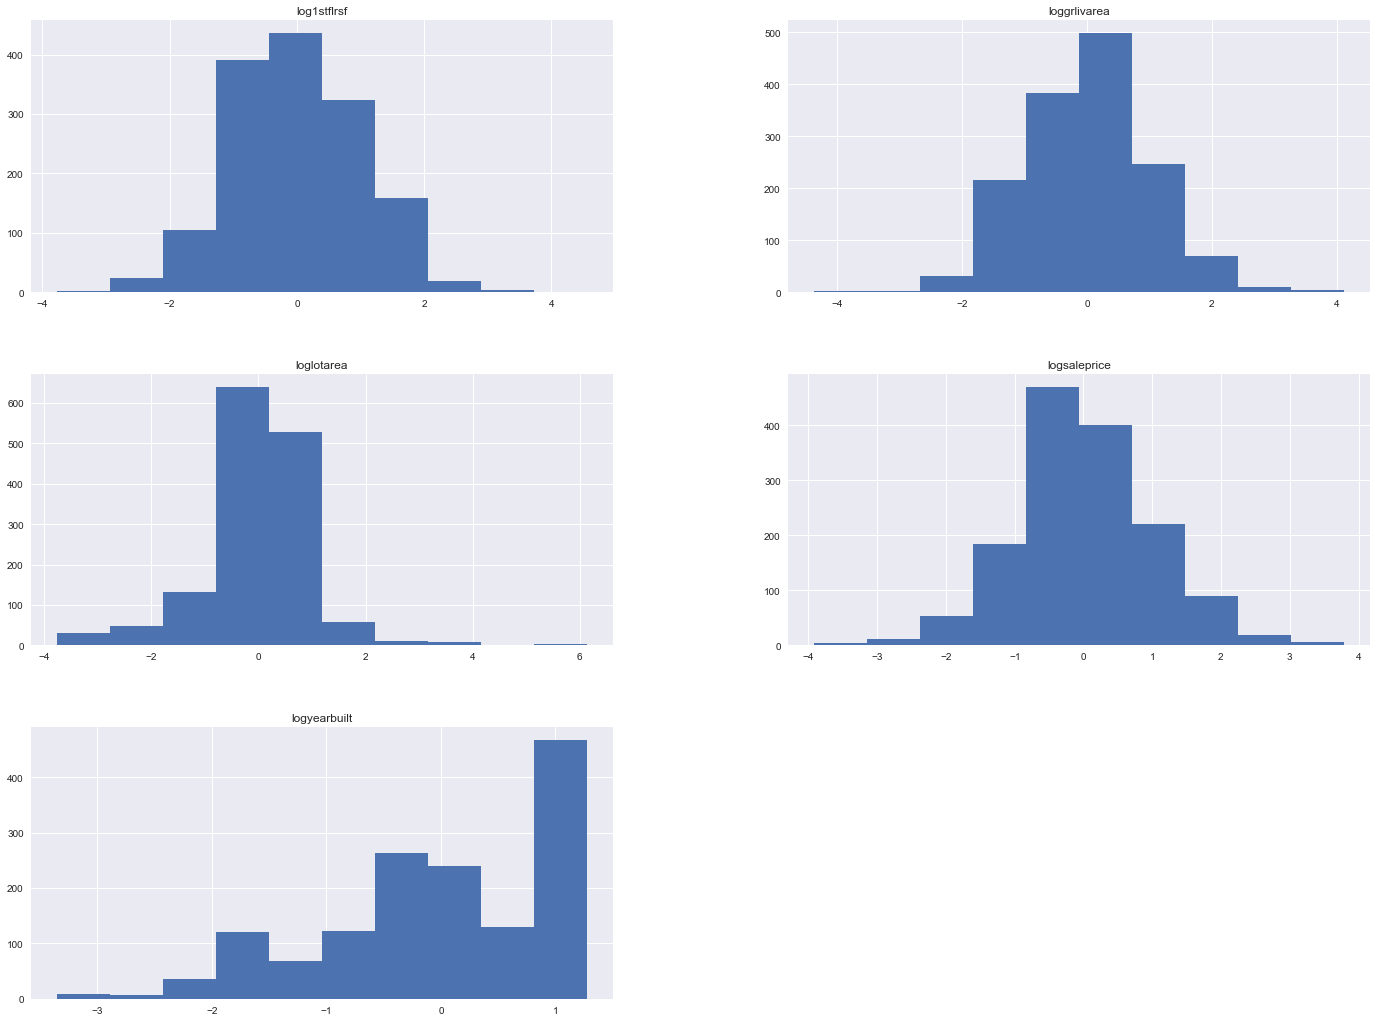

In [67]:
scaler = StandardScaler()
scaled = pd.DataFrame(scaler.fit_transform(ames_log), columns=ames_log.columns)
scaled.hist(figsize=(24,18))

## Summary
Great! You've now got some hands-on practice transforming data using log transforms, feature scaling, and normalization!